# Descripción del proyecto

Los clientes de Beta Bank se están yendo, cada mes, poco a poco. Los banqueros descubrieron que es más barato salvar a los clientes existentes que atraer nuevos.

Necesitamos predecir si un cliente dejará el banco pronto. Tú tienes los datos sobre el comportamiento pasado de los clientes y la terminación de contratos con el banco.

Crea un modelo con el máximo valor F1 posible. Para aprobar la revisión, necesitas un valor F1 de al menos 0.59. Verifica F1 para el conjunto de prueba. 

Además, debes medir la métrica AUC-ROC y compararla con el valor F1.


## Instrucciones del proyecto
1. Descarga y prepara los datos.  Explica el procedimiento.
2. Examina el equilibrio de clases. Entrena el modelo sin tener en cuenta el desequilibrio. Describe brevemente tus hallazgos.
3. Mejora la calidad del modelo. Asegúrate de utilizar al menos dos enfoques para corregir el desequilibrio de clases. Utiliza conjuntos de entrenamiento y validación para encontrar el mejor modelo y el mejor conjunto de parámetros. Entrena diferentes modelos en los conjuntos de entrenamiento y validación. Encuentra el mejor. Describe brevemente tus hallazgos.
4. Realiza la prueba final.

## Características

-RowNumber: índice de cadena de datos

-CustomerId: identificador de cliente único

-Surname: apellido

-CreditScore: valor de crédito

-Geography: país de residencia

-Gender: sexo

-Age: edad

-Tenure: período durante el cual ha madurado el depósito a plazo fijo de un cliente (años)

-Balance: saldo de la cuenta

-NumOfProducts: número de productos bancarios utilizados por el cliente

-HasCrCard: el cliente tiene una tarjeta de crédito (1 - sí; 0 - no)

-IsActiveMember: actividad del cliente (1 - sí; 0 - no)

-EstimatedSalary: salario estimado

Objetivo

-Exited: El cliente se ha ido (1 - sí; 0 - no)


In [51]:
#Empezando con el proyecto lo primero es importar las librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_curve, auc, precision_score, recall_score, f1_score, roc_auc_score, classification_report

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer



In [2]:
#Ahora hay que cargar los datos
df = pd.read_csv('Churn.csv')
display(df.head())
df.info()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB


In [3]:
#Vemos que hay 10000 filas y vemos que la unica que tiene datos nulos es en la columna de Tenure.
#Vamos a ver los datos nulos
df.isnull().sum()
#Vemos que hay 909 nulos en la columna de Tenure
#Vamos a ver cuantos datos unicos hay en la columna de Tenure
df['Tenure'].nunique()
#Vemos que hay 11 datos unicos
#Vamos a ver cuales son esos datos unicos
df['Tenure'].unique()
#Vamos a mostras las filas de la columna de Tenure que tienen datos nulos
df[df['Tenure'].isnull()].head(20)



,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
30,31,15589475,Azikiwe,591,Spain,Female,39,NaN,0.00,3,1,0,140469.38,1
48,49,15766205,Yin,550,Germany,Male,38,NaN,103391.38,1,0,1,90878.13,0
51,52,15768193,Trevisani,585,Germany,Male,36,NaN,146050.97,2,0,0,86424.57,0
53,54,15702298,Parkhill,655,Germany,Male,41,NaN,125561.97,1,0,0,164040.94,1
60,61,15651280,Hunter,742,Germany,Male,35,NaN,136857.00,1,0,0,84509.57,0
82,83,15641732,Mills,543,France,Female,36,NaN,0.00,2,0,0,26019.59,0
85,86,15805254,Ndukaku,652,Spain,Female,75,NaN,0.00,2,1,1,114675.75,0
94,95,15676966,Capon,730,Spain,Male,42,NaN,0.00,2,0,1,85982.47,0
99,100,15633059,Fanucci,413,France,Male,34,NaN,0.00,2,0,0,6534.18,0
111,112,15665790,Rowntree,538,Germany,Male,39,NaN,108055.10,2,1,0,27231.26,0


In [4]:
#Al revisar los datos veo que no hay ninguna razon por la que son Nulos, pero lo que si se es que hay mucha informacion importante.
#Por lo que no puedo eliminar esas filas. Lo que si hare sera reemplazar los datos nulos por la media/mediana de la columna.
#Primero vamos a ver la media y mediana de la columna Tenure
mean_tenure = df['Tenure'].mean()
median_tenure = df['Tenure'].median()
print(f'Mean: {mean_tenure}, Median: {median_tenure}')
#Vemos que la media es de 4.99 y la mediana es de 5.0, como estamos trabajando con numeros enteros vamos a usar la mediana.
#Vamos a reemplazar los datos nulos por la mediana
df['Tenure'].fillna(median_tenure, inplace=True)
#Vamos a verificar que ya no hay datos nulos
df.isnull().sum()
#Vemos que ya no hay datos nulos

Mean: 4.997690023099769, Median: 5.0


/var/folders/52/1m6xdwc12jq950g_76bq1l140000gn/T/ipykernel_61558/1137233683.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Tenure'].fillna(median_tenure, inplace=True)


RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [5]:
#Revisamos si hay duplicados
df.duplicated().sum()
#Vemos que no hay duplicados asi que revisamos los tipos de datos
df.dtypes
#La unica columna que deberia cambiar seria la de Tenure, a integer.
df['Tenure'] = df['Tenure'].astype(int)
df.dtypes
#Vemos que ya esta como integer

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [6]:
#Lo primero que hay que revisar es la diferencia de clases es decir cuantos clientes se han ido y cuantos no
df['Exited'].value_counts()
#Vemos que hay 7963 clientes que no se han ido y 2037 que si se han ido es decir un 79% a 21%


Exited
0    7963
1    2037
Name: count, dtype: int64

In [7]:
# Columnas categóricas y numéricas
cat_cols = ['Geography', 'Gender']
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

In [8]:
#Sabemos que tenemos columnas categoricas y numericas, por lo que hay que hacer un preprocesamiento de los datos.
#Lo primero que realizaremos sera eliminar las columnas que no aportaran informacion al modelo
df_model=df.drop(columns=['RowNumber','Surname','CustomerId'],axis=1)
df_model.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
#Ahora dividimos las variables en X e y
x=df_model.drop('Exited',axis=1)
y=df_model['Exited']
#Ahora separamos los datos en entrenamiento y prueba
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1103,stratify=y)


In [10]:
#Preprocesamiento de datos.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ])

In [11]:
# Ajustar el preprocessor a los datos de entrenamiento
X_train_processed = preprocessor.fit_transform(x_train)
X_test_processed = preprocessor.transform(x_test)
# Verificar las dimensiones
print(f"Forma de X_train_processed: {X_train_processed.shape}")
print(f"Forma de X_test_processed: {X_test_processed.shape}")


Forma de X_train_processed: (8000, 11)
Forma de X_test_processed: (2000, 11)


In [38]:
# Crear y entrenar el modelo
model_baseline = LogisticRegression(random_state=1103)
model_baseline.fit(X_train_processed, y_train)

# Hacer predicciones
y_pred = model_baseline.predict(X_test_processed)

# Calcular métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, model_baseline.predict_proba(X_test_processed)[:, 1])

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")


Accuracy: 0.8110
Precision: 0.5973
Recall: 0.2187
F1-Score: 0.3201
AUC-ROC: 0.7789


Con esto hemos realizado una prueba del modelo con los datos sin configurar o modificar las clases. De esta forma podemos ver que obtenemos un resultado de .80 en Accuracy, 0.56 de Precision, 0.21 en Recall y 0.31 en F1-Score. 

Un 80% parece un buen resultado en Accuracy. Sin embargo, este valor puede ser engañoso, por el desbalanceo de clases.

El 56% de precision es realmente bajo, esto significa que hay muchos Falsos Positivos (el modelo predice la clase positiva cuando en realidad es negativa).

El 21% de recall es un valor muy bajo. Significa que hay una gran cantidad de Falsos Negativos (el modelo predice la clase negativa cuando en realidad es positiva).

Por ultimo el 31% de F1-Score es bajo e indica que el modelo no tiene un buen equilibrio entre la calidad de las predicciones positivas (Precision) y la capacidad de encontrar todos los positivos (Recall).

# Paso 2.
Ahora realizaremos 2 formas de balancear las clases y realizar los modelos para ver los nuevos resultados.

In [39]:
#Empezaremos con el modelo con class_weight='balanced'
# Crear y entrenar el modelo con class_weight='balanced'
model_balanced = LogisticRegression(random_state=1103, class_weight='balanced')
model_balanced.fit(X_train_processed, y_train)

# Hacer predicciones
y_pred_balanced = model_balanced.predict(X_test_processed)

# Calcular métricas
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
precision_balanced = precision_score(y_test, y_pred_balanced)
recall_balanced = recall_score(y_test, y_pred_balanced)
f1_balanced = f1_score(y_test, y_pred_balanced)
auc_roc_balanced = roc_auc_score(y_test, model_balanced.predict_proba(X_test_processed)[:, 1])

print("Modelo con class_weight='balanced'")
print(f"Accuracy: {accuracy_balanced:.4f}")
print(f"Precision: {precision_balanced:.4f}")
print(f"Recall: {recall_balanced:.4f}")
print(f"F1-Score: {f1_balanced:.4f}")
print(f"AUC-ROC: {auc_roc_balanced:.4f}")

Modelo con class_weight='balanced'
Accuracy: 0.7155
Precision: 0.3905
Recall: 0.7101
F1-Score: 0.5039
AUC-ROC: 0.7836


La precisión general bajó 10 puntos. Esto era esperado, ya que el modelo ahora se esfuerza más por encontrar la clase minoritaria.

La precisión para la clase positiva bajó significativamente.

El modelo ahora encuentra tres veces más casos positivos reales (más del 60%). Esto demuestra que el ajuste funcionó para detectar la clase minoritaria.

Subió considerablemente. Esto indica un mejor equilibrio general, aunque el modelo ahora sacrifica algo de precisión (Precision) para obtener mucha más detección (Recall).

Sin embargo seguimos por debajo del porcentaje pedido.

Ahora balancearemos de otra forma.


In [14]:
#Probamos con submuestreo
from sklearn.utils import resample

# Separar las clases en el conjunto de entrenamiento
X_train_df = pd.DataFrame(X_train_processed)
y_train_df = pd.DataFrame(y_train).reset_index(drop=True)

# Combinar X e y para facilitar el muestreo
train_data = pd.concat([X_train_df, y_train_df], axis=1)

# Separar por clases
class_0 = train_data[train_data['Exited'] == 0]  # Clase mayoritaria
class_1 = train_data[train_data['Exited'] == 1]  # Clase minoritaria

print(f"Clase 0 (no se fueron): {len(class_0)}")
print(f"Clase 1 (se fueron): {len(class_1)}")

# Submuestreo de la clase mayoritaria
class_0_downsampled = resample(class_0, 
                              replace=False,    # sin reemplazo
                              n_samples=len(class_1),  # igualar a clase minoritaria
                              random_state=1103)

# Combinar las clases balanceadas
balanced_data = pd.concat([class_0_downsampled, class_1])
# Separar nuevamente X e y
X_train_balanced = balanced_data.drop('Exited', axis=1).values
y_train_balanced = balanced_data['Exited'].values
print(f"Datos balanceados - Clase 0: {sum(y_train_balanced == 0)}")
print(f"Datos balanceados - Clase 1: {sum(y_train_balanced == 1)}")

Clase 0 (no se fueron): 6370
Clase 1 (se fueron): 1630
Datos balanceados - Clase 0: 1630
Datos balanceados - Clase 1: 1630


In [40]:
# Entrenar modelo con datos balanceados por submuestreo
model_undersampled = LogisticRegression(random_state=1103)
model_undersampled.fit(X_train_balanced, y_train_balanced)

# Hacer predicciones en el conjunto de prueba
y_pred_undersampled = model_undersampled.predict(X_test_processed)

# Calcular métricas
accuracy_under = accuracy_score(y_test, y_pred_undersampled)
precision_under = precision_score(y_test, y_pred_undersampled)
recall_under = recall_score(y_test, y_pred_undersampled)
f1_under = f1_score(y_test, y_pred_undersampled)
auc_roc_under = roc_auc_score(y_test, model_undersampled.predict_proba(X_test_processed)[:, 1])

print("Modelo con Submuestreo (Undersampling)")
print(f"Accuracy: {accuracy_under:.4f}")
print(f"Precision: {precision_under:.4f}")
print(f"Recall: {recall_under:.4f}")
print(f"F1-Score: {f1_under:.4f}")
print(f"AUC-ROC: {auc_roc_under:.4f}")

Modelo con Submuestreo (Undersampling)
Accuracy: 0.7180
Precision: 0.3935
Recall: 0.7125
F1-Score: 0.5070
AUC-ROC: 0.7852


El submuestreo ha creado el modelo más efectivo hasta ahora.

Lo bueno: El Recall es excelente, y el F1-Score supera el 0.50.

Lo malo: La Precision sigue siendo baja (menos del 40%), lo que significa que de cada 10 predicciones positivas, casi 6 son incorrectas (Falsos Positivos). Y seguimos sin llegar al resultado del 59% en F1-Score.


In [21]:
# Obtener probabilidades en lugar de predicciones directas
y_proba_undersampled = model_undersampled.predict_proba(X_test_processed)[:, 1]

# Probar diferentes umbrales
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:
    y_pred_threshold = (y_proba_undersampled >= threshold).astype(int)
    
    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(f"Umbral: {threshold}\t, Precision: {precision:.4f}\t\tRecall: {recall:.4f}\t\tF1-Score: {f1:.4f}")

Umbral: 0.3	, Precision: 0.2813		Recall: 0.9263		F1-Score: 0.4316
Umbral: 0.4	, Precision: 0.3376		Recall: 0.8428		F1-Score: 0.4821
Umbral: 0.5	, Precision: 0.3935		Recall: 0.7125		F1-Score: 0.5070
Umbral: 0.6	, Precision: 0.4520		Recall: 0.5553		F1-Score: 0.4983
Umbral: 0.7	, Precision: 0.5138		Recall: 0.4128		F1-Score: 0.4578


In [41]:
#Tratemos con RandomForest
from sklearn.ensemble import RandomForestClassifier
model_rf=RandomForestClassifier(random_state=1103)
model_rf.fit(X_train_processed,y_train)
y_pred_rf=model_rf.predict(X_test_processed)
accuracy_rf=accuracy_score(y_test,y_pred_rf)
precision_rf=precision_score(y_test,y_pred_rf)
recall_rf=recall_score(y_test,y_pred_rf)
f1_rf=f1_score(y_test,y_pred_rf)
auc_roc_rf = roc_auc_score(y_test, model_rf.predict_proba(X_test_processed)[:, 1])
print("Random Forest")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")
print(f"AUC-ROC: {auc_roc_rf:.4f}")

Random Forest
Accuracy: 0.8670
Precision: 0.7681
Recall: 0.4963
F1-Score: 0.6030
AUC-ROC: 0.8723


In [42]:
#Ahora con RandomForest y submuestreo
model_rf_under=RandomForestClassifier(random_state=1103)
model_rf_under.fit(X_train_balanced,y_train_balanced)
y_pred_rf_under=model_rf_under.predict(X_test_processed)
accuracy_rf_under=accuracy_score(y_test,y_pred_rf_under)
precision_rf_under=precision_score(y_test,y_pred_rf_under)
recall_rf_under=recall_score(y_test,y_pred_rf_under)
f1_rf_under=f1_score(y_test,y_pred_rf_under)
auc_roc_under = roc_auc_score(y_test, model_rf_under.predict_proba(X_test_processed)[:, 1])
print("Random Forest con Submuestreo")
print(f"Accuracy: {accuracy_rf_under:.4f}")
print(f"Precision: {precision_rf_under:.4f}")
print(f"Recall: {recall_rf_under:.4f}")
print(f"F1-Score: {f1_rf_under:.4f}")
print(f"AUC-ROC: {auc_roc_under:.4f}")

Random Forest con Submuestreo
Accuracy: 0.8025
Precision: 0.5096
Recall: 0.7789
F1-Score: 0.6161
AUC-ROC: 0.8727


Random Forest con Submuestreo: F1-Score = 0.6161 
- Superando el objetivo 0.59
- Excelente balance: Precision 0.51, Recall 0.78

Random Forest sin modificadores: F1-Score = 0.6030 
- También supera el objetivo
- Precision muy alta (0.77) pero recall más bajo (0.50)

Con submuestreo: Mejor recall (detectas más clientes que se van)

Sin submuestreo: Mejor precision (menos falsos positivos)

En este mundo de bancos, con el objetivo de la empresa que es tratar de no perder clientes, porque es mas caro obtener nuevoso que salvar a los que ya se tienen. Es mas importante mantener un recall mas alto, no tanto la precision, es decir, es mas importante gastar mas recursos en retener a gente que no se iban a ir, que perder a mas clientes, es decir, mas vale ir a lo seguro y detectar a mas gente que se piensa ir para retenerlos.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier


# Definir los parámetros para GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Crear el modelo Random Forest
rf_model = RandomForestClassifier(random_state=1103)

# Configurar GridSearchCV con F1-score como métrica
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring='f1',
    cv=5,  # validación cruzada de 5 folds
    n_jobs=-1,  # usar todos los procesadores disponibles
    verbose=1  # mostrar progreso
)

# Entrenar con los datos balanceados (submuestreo)
print("Iniciando GridSearchCV con 108 combinaciones...")
grid_search.fit(X_train_balanced, y_train_balanced)

# Mostrar los mejores parámetros
print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor F1-Score (validación cruzada): {grid_search.best_score_:.4f}")


Iniciando GridSearchCV con 108 combinaciones...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Mejores parámetros: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Mejor F1-Score (validación cruzada): 0.7614


Exception ignored in: <function ResourceTracker.__del__ at 0x1047a5bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x120959bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x103839bc0>
Traceback (most recent call last

In [43]:
# Crear el modelo final con los mejores parámetros
modelo_final = RandomForestClassifier(
    max_depth=None,
    min_samples_leaf=1, 
    min_samples_split=5,
    n_estimators=100,
    random_state=1103
)

# Entrenar con todos los datos balanceados
modelo_final.fit(X_train_balanced, y_train_balanced)
#Predicion final
y_pred_final = modelo_final.predict(X_test_processed)
y_pred_proba_final = modelo_final.predict_proba(X_test_processed)[:, 1]

# Calcular métricas finales
f1_final = f1_score(y_test, y_pred_final)
auc_roc_final = roc_auc_score(y_test, y_pred_proba_final)
recall_final = recall_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final)


print("EVALUACION FINAL")
print(f"F1-Score en conjunto de prueba: {f1_final:.4f}")
print(f"AUC-ROC en conjunto de prueba: {auc_roc_final:.4f}")
print(f"Recall en conjunto de prueba: {recall_final:.4f}")
print(f"Precision en conjunto de prueba: {precision_final:.4f}")



EVALUACION FINAL
F1-Score en conjunto de prueba: 0.6086
AUC-ROC en conjunto de prueba: 0.8722
Recall en conjunto de prueba: 0.7813
Precision en conjunto de prueba: 0.4984


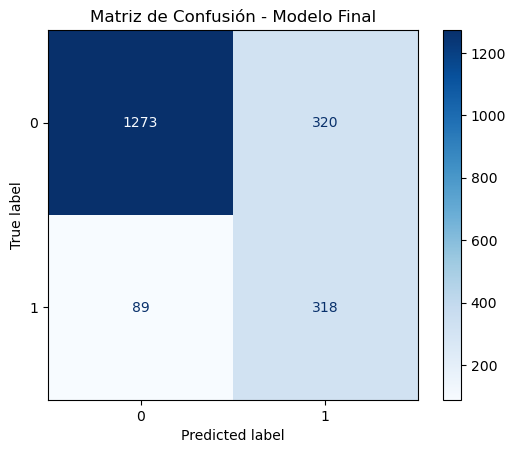

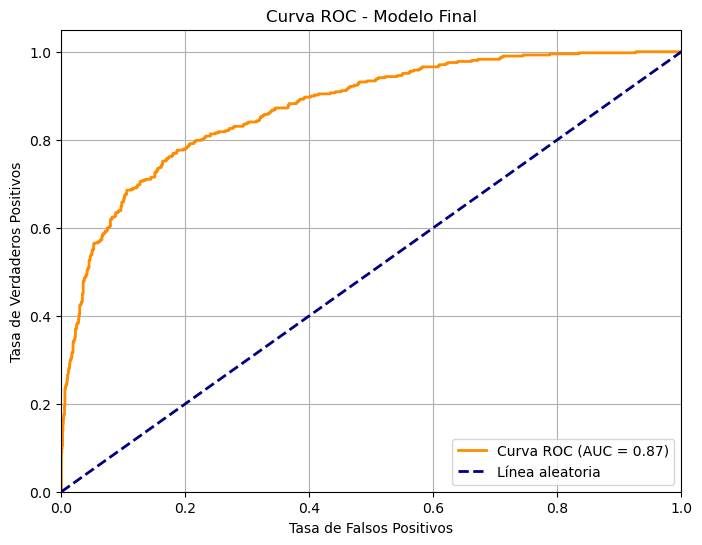

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.93      0.80      0.86      1593
           1       0.50      0.78      0.61       407

    accuracy                           0.80      2000
   macro avg       0.72      0.79      0.74      2000
weighted avg       0.85      0.80      0.81      2000



In [52]:
#Agregaremos una matriz de confusion y una grafica para visualizar mejor los resultados
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo_final.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Modelo Final")
plt.show()
# Obtener las probabilidades
y_proba = modelo_final.predict_proba(X_test_processed)[:, 1]

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Crear la gráfica
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Línea aleatoria')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - Modelo Final')
plt.legend(loc="lower right")
plt.grid()
plt.show()
# 6.2. Reporte de clasificación
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_final))

Estos resultados en conclusion nos dice que tenemos un muy buen modelo que cumple con las expectativas del proyecto.

Tenemos un F1-score que supera el 0.59 que se habia pedido en el proyecto, en el modelo entrenado nos daba resultados mas altos y ahora bajo, pero eso sigue siendo normal y 0.60 sigue siendo un resultado muy apropiado para el modelo.

Tambien obtuvioms un resultado de recall de 0.78 y de precision de 0.49, que en realidad es justo lo que pensabamos y buscabamos porque en este proyecto como se menciono anteriormente es mas importante tener un mayor recall que precision, para de esa forma evitar perder la mayor cantidad de clientes con este modelo.

Obtuvimos un resultado de AUC-ROC del 0.87 lo que nos dice que tenemos un modelo excepcional para distinguir entre las clases positiva y negativa en cualquier umbral de probabilidad.